# 06 - Baseline Models (Daily Data)

**Models**: Random Forest, XGBoost
**Data**: Daily features, 3-class moneyness target (ATM/OTM5/OTM10)
**Split**: Time-based (train < 2022-07, test >= 2022-07)

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.utils.class_weight import compute_class_weight
from xgboost import XGBClassifier

plt.style.use('seaborn-v0_8-whitegrid')

PROCESSED = Path('../data/processed')
MODELS = Path('../models')
MODELS.mkdir(parents=True, exist_ok=True)
SEED = 42
np.random.seed(SEED)

label_names = {0: 'ATM', 1: 'OTM5', 2: 'OTM10'}

## 1. Load Daily Modeling Data

In [2]:
data = pd.read_parquet(PROCESSED / 'daily_modeling_data.parquet')
data['date'] = pd.to_datetime(data['date'])
print(f"Data shape: {data.shape}")
print(f"Date range: {data['date'].min().date()} to {data['date'].max().date()}")
print(f"\nLabel distribution:")
for l, n in label_names.items():
    c = (data['label_3'] == l).sum()
    print(f"  {l} ({n}): {c:,} ({c/len(data)*100:.1f}%)")

Data shape: (29273, 34)
Date range: 2008-02-01 to 2025-12-31

Label distribution:
  0 (ATM): 18,152 (62.0%)
  1 (OTM5): 5,005 (17.1%)
  2 (OTM10): 6,116 (20.9%)


## 2. Time-Based Split

In [3]:
# Feature columns
exclude = ['symbol', 'date', 'year_month', 'best_moneyness', 'best_return', 'label_3', 'year']
feature_cols = [c for c in data.columns if c not in exclude]

# Time split
unique_dates = data['date'].sort_values().unique()
split_date = unique_dates[int(len(unique_dates) * 0.8)]

train_mask = data['date'] < split_date
test_mask = data['date'] >= split_date

X_train = data.loc[train_mask, feature_cols].copy()
X_test = data.loc[test_mask, feature_cols].copy()
y_train = data.loc[train_mask, 'label_3'].copy()
y_test = data.loc[test_mask, 'label_3'].copy()

# Fill missing with train median
med = X_train.median()
X_train = X_train.fillna(med)
X_test = X_test.fillna(med)

# Class weights
cw = compute_class_weight('balanced', classes=np.array([0,1,2]), y=y_train)
cw_dict = dict(enumerate(cw))

print(f"Split date: {pd.Timestamp(split_date).date()}")
print(f"Train: {len(X_train):,} rows, Test: {len(X_test):,} rows")
print(f"Features: {len(feature_cols)}")

Split date: 2022-06-14
Train: 21,395 rows, Test: 7,878 rows
Features: 27


## 3. Random Forest

In [4]:
rf = RandomForestClassifier(n_estimators=200, max_depth=10, min_samples_leaf=5,
                           class_weight=cw_dict, random_state=SEED, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("Random Forest Results:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"  Macro F1: {f1_score(y_test, y_pred_rf, average='macro'):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=['ATM', 'OTM5', 'OTM10']))

Random Forest Results:
  Accuracy: 0.4853
  Macro F1: 0.3328
              precision    recall  f1-score   support

         ATM       0.55      0.76      0.63      4119
        OTM5       0.08      0.04      0.06      1099
       OTM10       0.40      0.25      0.31      2660

    accuracy                           0.49      7878
   macro avg       0.34      0.35      0.33      7878
weighted avg       0.43      0.49      0.44      7878



## 4. XGBoost

In [5]:
sw = y_train.map(cw_dict).values
xgb = XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, subsample=0.8,
                    colsample_bytree=0.8, random_state=SEED, use_label_encoder=False,
                    eval_metric='mlogloss', n_jobs=-1)
xgb.fit(X_train, y_train, sample_weight=sw)
y_pred_xgb = xgb.predict(X_test)

print("XGBoost Results:")
print(f"  Accuracy: {accuracy_score(y_test, y_pred_xgb):.4f}")
print(f"  Macro F1: {f1_score(y_test, y_pred_xgb, average='macro'):.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=['ATM', 'OTM5', 'OTM10']))

XGBoost Results:
  Accuracy: 0.4799
  Macro F1: 0.3591
              precision    recall  f1-score   support

         ATM       0.56      0.75      0.64      4119
        OTM5       0.15      0.18      0.16      1099
       OTM10       0.47      0.19      0.27      2660

    accuracy                           0.48      7878
   macro avg       0.39      0.37      0.36      7878
weighted avg       0.47      0.48      0.45      7878



## 5. Comparison and Feature Importance

Baseline Comparison:
        Model  Accuracy  Macro F1
Random Forest    0.4853    0.3328
      XGBoost    0.4799    0.3591


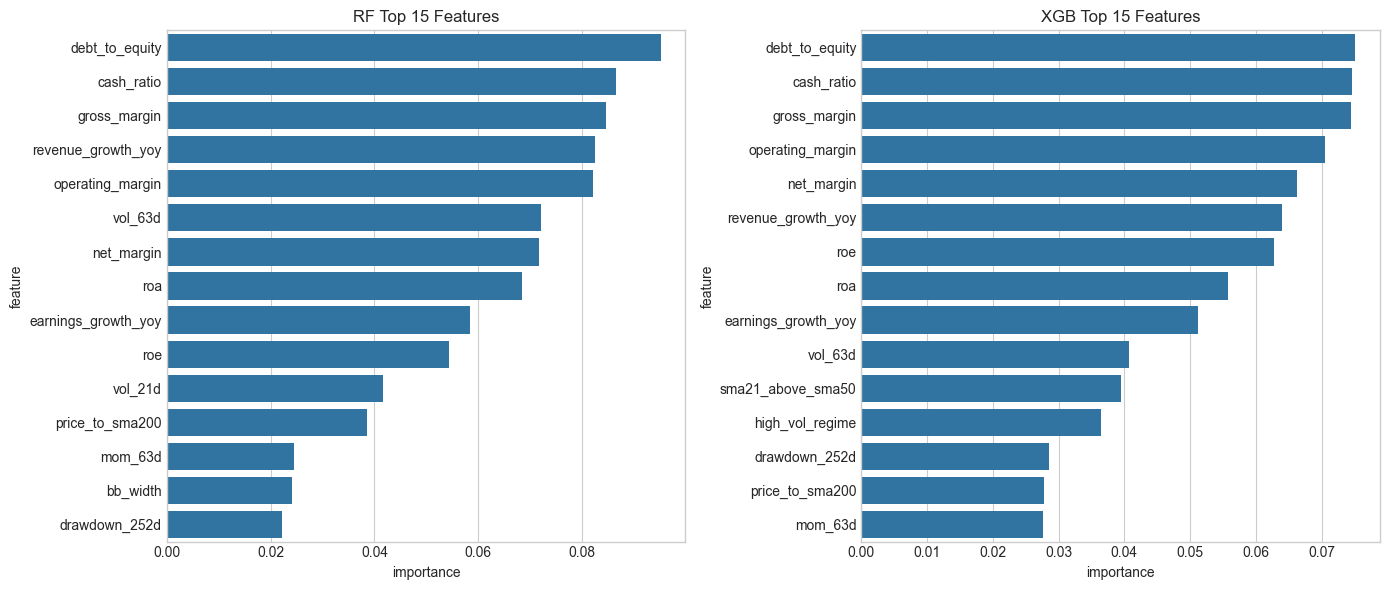

In [6]:
results = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'Accuracy': [accuracy_score(y_test, y_pred_rf), accuracy_score(y_test, y_pred_xgb)],
    'Macro F1': [f1_score(y_test, y_pred_rf, average='macro'), f1_score(y_test, y_pred_xgb, average='macro')],
}).round(4)
print("Baseline Comparison:")
print(results.to_string(index=False))

# Feature importance
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, model, name in zip(axes, [rf, xgb], ['RF', 'XGB']):
    imp = pd.DataFrame({'feature': feature_cols, 'importance': model.feature_importances_}).sort_values('importance', ascending=False)
    sns.barplot(data=imp.head(15), x='importance', y='feature', ax=ax)
    ax.set_title(f'{name} Top 15 Features')
plt.tight_layout()
plt.savefig('../reports/figures/baseline_feature_importance.png', dpi=150)
plt.show()

## 6. Confusion Matrices

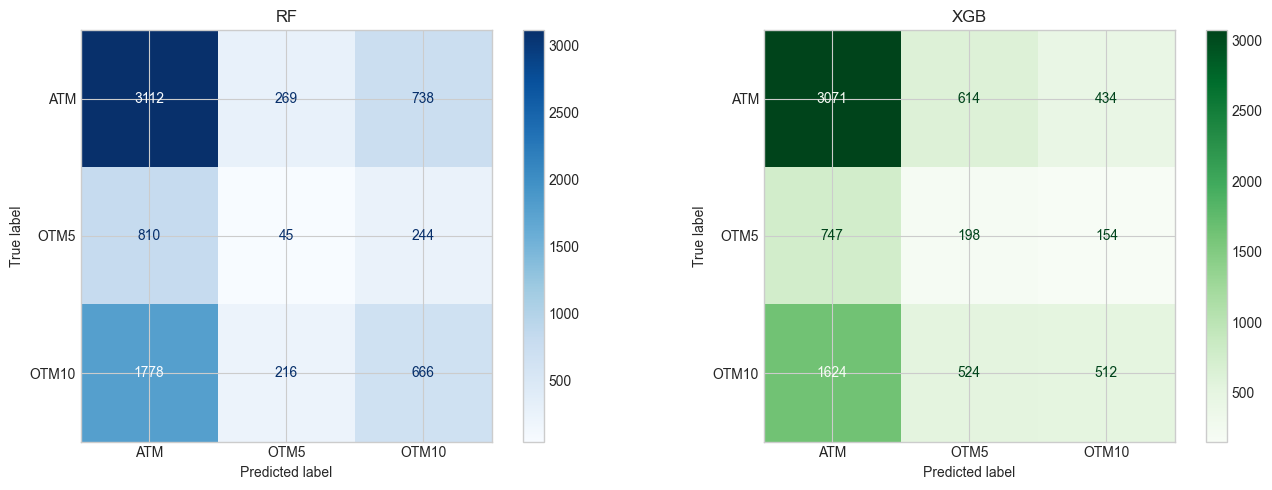

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, preds, name, cmap in zip(axes, [y_pred_rf, y_pred_xgb], ['RF', 'XGB'], ['Blues', 'Greens']):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['ATM','OTM5','OTM10']).plot(ax=ax, cmap=cmap, values_format='d')
    ax.set_title(name)
plt.tight_layout()
plt.savefig('../reports/figures/baseline_confusion.png', dpi=150)
plt.show()

## 7. Save

In [8]:
joblib.dump(rf, MODELS / 'rf_baseline.joblib')
joblib.dump(xgb, MODELS / 'xgb_baseline.joblib')
results.to_csv(PROCESSED / 'baseline_results.csv', index=False)
print("Baseline models saved.")

Baseline models saved.
